<a href="https://colab.research.google.com/github/Koks-creator/FaceGenerating/blob/main/WGAN2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()  # wgraj kaggle.json

!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip celeba-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: img_align_celeba/img_align_celeba/197605.jpg  
  inflating: img_align_celeba/img_align_celeba/197606.jpg  
  inflating: img_align_celeba/img_align_celeba/197607.jpg  
  inflating: img_align_celeba/img_align_celeba/197608.jpg  
  inflating: img_align_celeba/img_align_celeba/197609.jpg  
  inflating: img_align_celeba/img_align_celeba/197610.jpg  
  inflating: img_align_celeba/img_align_celeba/197611.jpg  
  inflating: img_align_celeba/img_align_celeba/197612.jpg  
  inflating: img_align_celeba/img_align_celeba/197613.jpg  
  inflating: img_align_celeba/img_align_celeba/197614.jpg  
  inflating: img_align_celeba/img_align_celeba/197615.jpg  
  inflating: img_align_celeba/img_align_celeba/197616.jpg  
  inflating: img_align_celeba/img_align_celeba/197617.jpg  
  inflating: img_align_celeba/img_align_celeba/197618.jpg  
  inflating: img_align_celeba/img_align_celeba/197619.jpg  
  inflating: img_align_celeba/img_align_celeba/19

In [ ]:
from typing import Union, List, Tuple
from pathlib import Path
import csv
import os
import pathlib
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
MAIN_DIR = "/content/img_align_celeba/img_align_celeba"
IMG_SIZE = 64       # scale to 64x64
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
LATENT_DIM = 128
CHECKPOINT_PATH = "/content/drive/MyDrive/face_gan/"

In [ ]:
drive.mount('/content/drive')
CHECKPOINT_DIR = os.path.dirname(CHECKPOINT_PATH)

Mounted at /content/drive


In [ ]:
def load_and_prepare(path: Union[str, Path]):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # CelebA centres faces — we crop the centre instead of stretching
    img = tf.image.resize_with_crop_or_pad(img, 128, 128)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    img = (tf.cast(img, tf.float32) - 127.5) / 127.5
    return img

In [ ]:
all_paths = tf.data.Dataset.list_files(f"{MAIN_DIR}/*.jpg", shuffle=True)

dataset = (
    all_paths
    .map(load_and_prepare, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)

print(f"Batch count: {len(dataset)}")
sample = next(iter(dataset))
print(f"Batch size: {sample.shape}")   # (128, 64, 64, 3)
print(f"Min: {sample.numpy().min():.2f}, Max: {sample.numpy().max():.2f}")  # -1.0 do 1.0

Batch count: 1582
Batch size: (128, 64, 64, 3)
Min: -1.00, Max: 1.00


# WGAN v2.5 — Wasserstein GAN with Gradient Penalty

## 1. THE BIG PICTURE: WHY WGAN BEATS REGULAR GAN

A regular GAN is like a forger versus a detective.
  - Generator     = forger making fake paintings
  - Discriminator = detective answering yes/no: "fake or real?"

The problem: the detective gets too good too fast. Once they say
"100% fake" with full confidence, the forger has no idea how close
they were to fooling them. The signal becomes binary and learning
stalls. This is mode collapse — why classic GANs are notoriously
hard to train.

WGAN changes the game. The detective is replaced by a CRITIC who
gives a numeric SCORE instead of yes/no.
  - Real images → critic should give high scores
  - Fake images → critic should give low scores
  - Generator's goal: make fakes that score as high as possible

This gives the forger a gradient — a direction. Even if a fake is
clearly bad, the critic can say "this scored -8, that scored -3" —
so the generator knows which way to improve. This is the Wasserstein
distance idea: instead of "are these the same distribution?" (binary)
it asks "how far apart are they?" (continuous).

The math requires the critic to be 1-Lipschitz (its outputs can't
change too fast). We enforce this with Gradient Penalty (GP):
a loss term that punishes the critic if its gradients get too steep.
That's the "GP" in WGAN-GP.

Result: stable training, no mode collapse, smooth loss curves, and
the loss is actually readable — you can tell if training is going
well just by looking at the numbers.

This is the "no-frills" version — pure DCGAN-style architecture,
no Self-Attention, no fancy upsampling. Trains ~3x faster than v4
while still producing solid results.


## GENERATOR
Turns a 128-number latent vector (random noise) into a 64x64 RGB face. <br>
Strategy: start with a tiny 8x8 grid of abstract features, then
gradually GROW it (8→16→32→64) using transposed convolutions. <br>
As resolution grows, channel count drops — detail spreads across
more pixels instead of being stacked in channels.

In [ ]:
def build_generator(latent_dim=128):
    gen_input = tf.keras.Input(shape=(latent_dim,))

    # latent_dim = "latent dimension" — 128 independent "knobs" of
    # randomness, each sampled from N(0,1). Different knob settings
    # → different face. The generator learns during training which
    # knob controls which feature (smile, hair length, glasses, ...).
    #
    # Why two layers? Convs need a 4D tensor (batch, H, W, channels)
    # — they can't run on a flat vector. Dense learns to map the
    # noise into 16384 activations; Reshape just reinterprets them
    # as an 8x8x256 cube (zero params, zero compute).

    # 256 channels = starting capacity; halves at each upsample
    # (256→128→64→32). 8x8 because we upsample x2 three times → 64x64.
    # 8x8 because we'll upsample x2 (strides=2) three times to reach 64x64.
    x = layers.Dense(8 * 8 * 256, use_bias=False)(gen_input)
    x = layers.Reshape((8, 8, 256))(x)

    # LayerNorm (NOT BatchNorm!) — BatchNorm breaks Gradient Penalty
    # because GP needs each sample to be independent of others in the
    # batch, but BN makes them depend on each other through batch stats.
    x = layers.LayerNormalization()(x)

    # LeakyReLU instead of ReLU — keeps a tiny slope (0.2) on negatives
    # so gradients always flow. ReLU can "kill" neurons by zeroing them.
    x = layers.LeakyReLU(0.2)(x)

    # ── 8x8 → 16x16 ──
    # Conv2DTranspose = "convolution in reverse", doubles resolution
    # while learning what to fill in the new pixels.
    # kernel=4 with stride=2 — the kernel size MUST be divisible by
    # stride, otherwise you get checkerboard artifacts (those weird
    # grid patterns in GAN outputs). kernel=3, stride=2 = artifacts.
    # kernel=4, stride=2 = clean.
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2,
                               padding='same', use_bias=False)(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # ── 16x16 → 32x32 ──
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2,
                               padding='same', use_bias=False)(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # ── 32x32 → 64x64 ──
    x = layers.Conv2DTranspose(32, kernel_size=4, strides=2,
                               padding='same', use_bias=False)(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # ── Final RGB projection ──
    # Separate layer (not merged with the last upsample) for cleaner
    # output — combining upsample and channel reduction in one step
    # tends to produce visible artifacts.
    # tanh squashes output to [-1, 1], matching how training images
    # are normalized.
    fake_images = layers.Conv2D(3, kernel_size=3, padding='same',
                                activation='tanh')(x)

    return tf.keras.Model(gen_input, fake_images, name="generator")

## CRITIC
Mirror image of the generator: takes a 64x64 RGB image, gradually
SHRINKS it through strided convolutions, outputs a single score. <br>
64 → 32 → 16 → 8 → 4 → flatten → 1 number. <br>
As resolution shrinks, channels grow (64 → 128 → 256 → 256) — the
network captures higher-level concepts (edges → textures → face
parts → whole-face structure).

In [ ]:
def build_critic(img_shape=(64, 64, 3)):
    disc_input = tf.keras.Input(shape=img_shape)

    # ── 64x64 → 32x32 ──
    # kernel=4 with stride=2 — same reasoning as in the generator,
    # clean math, no gradient artifacts.
    # No LayerNorm on the first layer — standard practice.
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(disc_input)
    x = layers.LeakyReLU(0.2)(x)

    # Dropout in the critic — controversial in WGAN-GP theory because
    # GP enforces a smoothness constraint on the critic, and dropout
    # adds randomness that fights against it. BUT in practice, for
    # small models on CelebA, dropout stabilizes training. We tested
    # both with and without — dropout version converges more reliably.
    x = layers.Dropout(0.2)(x)

    # ── 32x32 → 16x16 ──
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    # ── 16x16 → 8x8 ──
    x = layers.Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    # ── 8x8 → 4x4 ──
    x = layers.Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Flatten()(x)

    # Dense(1) — single scalar score. NO sigmoid! Unlike a regular GAN
    # discriminator that outputs a probability in [0,1], the critic
    # outputs an unbounded real number. Higher = more "real-looking".
    x = layers.Dense(1)(x)

    return tf.keras.Model(disc_input, x, name="critic")

In [ ]:
class WGAN(tf.keras.Model):
    def __init__(self, generator, critic, latent_dim, critic_steps=5, gp_weight=10.0):
        super().__init__()
        self.generator = generator
        self.critic = critic
        self.latent_di = latent_dim
        self.critic_steps = critic_steps
        self.gp_weight = gp_weight

    def compile(self, gen_optimizer, critic_optimizer):
        super().compile()
        self.gen_optimizer = gen_optimizer
        self.critic_optimizer = critic_optimizer
        self.gen_loss_metric = tf.keras.metrics.Mean(name="gen_loss")
        self.critic_loss_metric = tf.keras.metrics.Mean(name="critic_loss")

    @property
    def metrics(self):
        return [self.gen_loss_metric, self.critic_loss_metric]

    def gradient_penalty(self, real_images, fake_images, batch_size):
        # A random point between the real and the fake image
        alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        interpolated = real_images + alpha * (fake_images - real_images)

        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = self.critic(interpolated, training=True)

        grads = tape.gradient(pred, interpolated)
        norm  = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))

        # Punish gradient norm differs from 1
        return tf.reduce_mean((norm - 1.0) ** 2)

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        for _ in range(self.critic_steps):
            noise = tf.random.normal([batch_size, self.latent_dim])
            with tf.GradientTape() as critic_tape:
                fake_images = self.generator(noise, training=True)
                real_output = self.critic(real_images, training=True)
                fake_output = self.critic(fake_images, training=True)

                # Wasserstein loss
                critic_loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output)

                # Gradient penalty
                gp = self.gradient_penalty(real_images, fake_images, batch_size)
                critic_loss = critic_loss + self.gp_weight * gp

            critic_grads = critic_tape.gradient(critic_loss, self.critic.trainable_variables)
            self.critic_optimizer.apply_gradients(zip(critic_grads, self.critic.trainable_variables))

        noise = tf.random.normal([batch_size, self.latent_dim])
        with tf.GradientTape() as gen_tape:
            fake_images = self.generator(noise, training=True)
            fake_output = self.critic(fake_images, training=True)

            # Generator chce żeby krytyk dawał wysokie oceny fałszywym obrazom
            gen_loss = -tf.reduce_mean(fake_output)

        gen_grads = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        self.gen_optimizer.apply_gradients(zip(gen_grads, self.generator.trainable_variables))

        self.gen_loss_metric.update_state(gen_loss)
        self.critic_loss_metric.update_state(critic_loss)
        return {m.name: m.result() for m in self.metrics}

In [ ]:
# ─────────────────────────────────────────
# CALLBACKS
# ─────────────────────────────────────────
class ImageSampleCallback(tf.keras.callbacks.Callback):
    def __init__(self, latent_dim, n=16):
        self.seed = tf.random.normal([n, latent_dim])

    def on_epoch_end(self, epoch, logs=None):
        if epoch > 0 and epoch % 10 == 0:
            generated = self.model.generator(self.seed, training=False)
            generated = (generated + 1.0) / 2.0  # [-1,1] → [0,1] from leaky relu

            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for i, ax in enumerate(axes.flat):
                ax.imshow(generated[i].numpy())
                ax.axis('off')
            plt.suptitle(f"Epoch {epoch + 1}")
            plt.tight_layout()
            plt.show()

class CustomCSVLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
        # self.epoch = 0

    def on_train_begin(self, logs=None):
        if not os.path.exists(self.log_path):
            self.csvfile = open(self.log_path, "w", newline='')
            self.writer = csv.writer(self.csvfile)
            self.writer.writerow(["epoch", "critic_loss", "gen_loss"])
            self.csvfile.flush()
            self.csvfile.close()

    def on_epoch_end(self, epoch: int, logs=None):
        self.csvfile = open(self.log_path, "a", newline="")
        self.writer = csv.writer(self.csvfile)
        logs = logs or {}

        row = [
            epoch,
            logs.get("critic_loss", "N/A"),
            logs.get("gen_loss", "N/A"),
        ]
        self.writer.writerow(row)
        self.csvfile.flush()
        self.csvfile.close()

    def on_train_end(self, logs=None) -> None:
        self.csvfile.close()

class SaveCheckpointCallback(tf.keras.callbacks.Callback):
    def __init__(self, save_dir):
          super().__init__()
          self.save_dir = save_dir
    def on_epoch_end(self, epoch, logs=None):
        self.model.generator.save_weights(f"{self.save_dir}/generator_epoch_{epoch+1}_v2.weights.h5")
        self.model.critic.save_weights(f"{self.save_dir}/critic_epoch_{epoch+1}_v2.weights.h5")
        print(f"\nSaving checkpoint — epoch {epoch+1}")

In [ ]:
CHECKPOINT_EPOCH = 0

if CHECKPOINT_EPOCH:
    print("Loading from checkpiont")
    print(f"{CHECKPOINT_DIR}/generator_epoch_{CHECKPOINT_EPOCH}_v2.weights.h5")
    print(f"{CHECKPOINT_DIR}/critic_epoch_{CHECKPOINT_EPOCH}_v2.weights.h5")

    generator = build_generator(LATENT_DIM)
    critic = build_critic()

    # Dummy forward pass
    generator(tf.random.normal([1, LATENT_DIM]))
    critic(tf.random.normal([1, 64, 64, 3]))

    generator.load_weights(f"{CHECKPOINT_DIR}/generator_epoch_{CHECKPOINT_EPOCH}_v2.weights.h5")
    critic.load_weights(f"{CHECKPOINT_DIR}/critic_epoch_{CHECKPOINT_EPOCH}_v2.weights.h5")
else:
    print("loading fresh model")
    generator = build_generator(LATENT_DIM)
    critic = build_critic()

wgan = WGAN(
    generator=generator,
    critic=critic,
    latent_dim=LATENT_DIM,
    critic_steps=5,
    gp_weight=10.0
)

w_sum_before = tf.reduce_sum(wgan.generator.layers[1].weights[0]).numpy()
print(f"gen first layer weights sum: {w_sum_before}")
wgan.compile(
    gen_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.0, beta_2=0.9),
    critic_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.0, beta_2=0.9),
)
w_sum_after = tf.reduce_sum(wgan.generator.layers[1].weights[0]).numpy()
print(f"gen first layer weights sum: {w_sum_before}")

assert w_sum_before == w_sum_after

Loading from checkpiont
/content/drive/MyDrive/face_gan/generator_epoch_13_v2.weights.h5
/content/drive/MyDrive/face_gan/critic_epoch_13_v2.weights.h5
gen first layer weights sum: 18.355812
gen first layer weights sum: 18.355812


In [ ]:
wgan.fit(
    dataset,
    epochs=30,
    initial_epoch=16,
    callbacks=[
        CustomCSVLogger(f"{CHECKPOINT_DIR}/training_log_wgan_v2.csv"),
        SaveCheckpointCallback(save_dir=CHECKPOINT_DIR)
    ]
)

Epoch 17/30
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - critic_loss: -0.7164 - gen_loss: -64.5787
Saving checkpoint — epoch 17
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 1152s 728ms/step - critic_loss: -0.6412 - gen_loss: -67.7145
Epoch 18/30
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - critic_loss: -0.2852 - gen_loss: -84.1542
Saving checkpoint — epoch 18
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 1154s 729ms/step - critic_loss: -0.1974 - gen_loss: -94.3270
Epoch 19/30
 239/1582 ━━━━━━━━━━━━━━━━━━━━ 16:17 727ms/step - critic_loss: -0.3613 - gen_loss: -114.6893

KeyboardInterrupt: 

# Save

In [ ]:
wgan.generator.save(f"{CHECKPOINT_DIR}/wgan_2_5_3_generator.h5")
wgan.critic.save(f"{CHECKPOINT_DIR}/wgan_2_5_3.critic.h5")


# Test

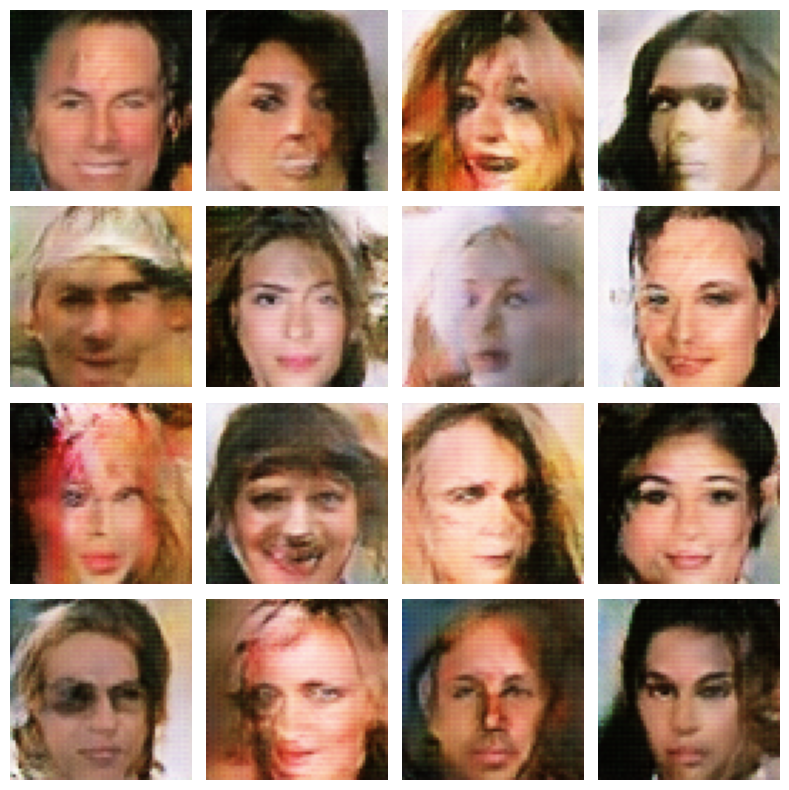

In [ ]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt


wgan.generator.save("generator.h5")
wgan.critic.save("critic.h5")

generator = load_model("generator.h5")
critic = load_model("critic.h5")


def generate_faces(generator, n=16):
    noise = tf.random.normal([n, 128])
    generated = generator(noise, training=False)
    generated = (generated + 1.0) / 2.0  # [-1,1] → [0,1]

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].numpy())
        ax.axis('off')
    plt.tight_layout()
    plt.show()

generate_faces(generator)